## Лабораторная работа №2
## Временные ряды

## Задачи
1) С помощью библиотек (openpyxl, pandas) получить доступ ко всем листам Excel-файла.
2) Очистить и унифицировать данные: привести к единому временному индексу, обработать пропуски и выбросы.
3) Провести анализ временного ряда: визуализация, проверка стационарности, декомпозиция на тренд, сезонность и остатки, спектральный анализ.
4) Извлечь из временного ряда признаки, полезные для прогнозирования.
5) Построить дерево решений, случайный лес и бустинг. Подобрать гиперпараметры через optuna. 
6) Использовать рекурсивную стратегию и стратегию создания модели на каждый из горизонтов. Сравнить результаты.
7) Оценить качество прогноза на тестовом отрезке с использованием метрик WAPE, MAE, MAPE, directional accuracy, directional r2.


Будем считать только непустые листы дата сета и добавлять в наш датасет 

In [103]:
import pandas as pd
import numpy as np
def read_nonempty_sheets(file_path):
    """
    Читает ВСЕ листы Excel, возвращает словарь только с непустыми DataFrame.
    Выводит названия непустых листов и их размеры.
    """
    nonempty_dfs = {}
    with pd.ExcelFile(file_path, engine='openpyxl') as xlsx:
        for sheet_name in xlsx.sheet_names:
            df = xlsx.parse(sheet_name)
            if not df.empty and not df.isna().all().all():
                nonempty_dfs[sheet_name] = df
                print(f"Непустой лист: {sheet_name} (строк: {df.shape[0]}, столбцов: {df.shape[1]})")
            else:
                print(f"Пропущен пустой лист: {sheet_name}")
    return nonempty_dfs

# Использование
file_path = 'have_fun.xlsx'
data_set = read_nonempty_sheets(file_path)

Непустой лист: Ëèñò1 (строк: 125124, столбцов: 10)
Пропущен пустой лист: Лист1
Пропущен пустой лист: ÌÀÈ
Пропущен пустой лист: ýòî
Пропущен пустой лист: ÿ
Пропущен пустой лист: !
Непустой лист: Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû (строк: 125276, столбцов: 21)
Непустой лист: Ëèñò3_ñìåøàííûå_òèïû (строк: 122736, столбцов: 10)


Подозрительно выглядит 2 непустой лист (открыв файл в хл я вижу только 10 столбцов )

In [104]:
for sheet_name, df in data_set.items():
    print(f"\n=== {sheet_name} ===")
    print(f"Всего столбцов: {df.shape[1]}")
    print("Первые 5 столбцов:", df.columns[:5].tolist())
    nonnull_counts = df.count()
    print("Столбцы с <= 1% непустых значений:")
    for col in nonnull_counts.index:
        pct = nonnull_counts[col] / len(df) * 100
        if pct < 1:  # почти пустой столбец
            print(f"  {col}: {nonnull_counts[col]} значений ({pct:.1f}%)")


=== Ëèñò1 ===
Всего столбцов: 10
Первые 5 столбцов: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall']
Столбцы с <= 1% непустых значений:

=== Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû ===
Всего столбцов: 21
Первые 5 столбцов: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall']
Столбцы с <= 1% непустых значений:
  Unnamed: 10: 0 значений (0.0%)
  Unnamed: 11: 1 значений (0.0%)
  Unnamed: 12: 1 значений (0.0%)
  Unnamed: 13: 1 значений (0.0%)
  Unnamed: 14: 41 значений (0.0%)
  Unnamed: 15: 41 значений (0.0%)
  Unnamed: 16: 41 значений (0.0%)
  Unnamed: 17: 41 значений (0.0%)
  Unnamed: 18: 41 значений (0.0%)
  Unnamed: 19: 41 значений (0.0%)
  Unnamed: 20: 41 значений (0.0%)

=== Ëèñò3_ñìåøàííûå_òèïû ===
Всего столбцов: 10
Первые 5 столбцов: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall']
Столбцы с <= 1% непустых значений:


Надо во втором листе почистить  Unnamed


In [105]:
def remove_unnamed_columns(df):
    """Удаляет все столбцы, названия которых начинаются с 'Unnamed'."""
    unnamed_cols = [col for col in df.columns if str(col).startswith('Unnamed')]
    if unnamed_cols:
        print(f"Удалены столбцы: {unnamed_cols}")
        return df.drop(columns=unnamed_cols)
    else:
        print("Столбцов Unnamed не найдено.")
        return df
fds = {}
for sheet_name, df in data_set.items():
    print(f"\nЛист: {sheet_name}")
    fds[sheet_name] = remove_unnamed_columns(df)
    print(f"Размер после очистки: {fds[sheet_name].shape}")


Лист: Ëèñò1
Столбцов Unnamed не найдено.
Размер после очистки: (125124, 10)

Лист: Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû
Удалены столбцы: ['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20']
Размер после очистки: (125276, 10)

Лист: Ëèñò3_ñìåøàííûå_òèïû
Столбцов Unnamed не найдено.
Размер после очистки: (122736, 10)


Был получен файл have_fun.xlsx.
В нем ошибка кодировки надо исправить 


In [106]:
from pandas.api.types import is_string_dtype

def fix_encoding(text):
    """Исправляет битую русскую кодировку (cp1252 -> cp1251)."""
    if not isinstance(text, str):
        return text
    try:
        return text.encode('cp1252').decode('cp1251')
    except (UnicodeEncodeError, UnicodeDecodeError):
        return text

def fix_dataframe_encoding(df):
    """Исправляет кодировку колонок и строковых значений в DataFrame."""
    df = df.copy()
    # Исправляем названия колонок
    df.columns = [fix_encoding(col) for col in df.columns]
    # Исправляем строковые столбцы (любого строкового типа)
    for col in df.columns:
        if is_string_dtype(df[col]):   # работает и с object, и с string
            df[col] = df[col].apply(lambda x: fix_encoding(x) if isinstance(x, str) else x)
    # Исправляем строковый индекс
    if is_string_dtype(df.index):
        df.index = [fix_encoding(idx) for idx in df.index]
    return df

def fix_all_sheets_encoding(sheets_dict):
    """
    Принимает словарь {имя_листа: DataFrame} с битой кодировкой.
    Возвращает новый словарь с исправленными именами листов и данными.
    """
    fixed_dict = {}
    for sheet_name, df in sheets_dict.items():
        new_name = fix_encoding(sheet_name)
        fixed_dict[new_name] = fix_dataframe_encoding(df)
    return fixed_dict

# Применение
fix_data = fix_all_sheets_encoding(fds)
for name, df in fix_data.items():
    print(f"Лист: {name}")
    print(df.head())

Лист: Лист1
   temperature_2m  relative_humidity_2m  precipitation  rain  snowfall  \
0        3.800000                    82            0.0   0.0       0.0   
1       -3.000000                    70            0.0   0.0       0.0   
2       -1.300000                    86            0.0   0.0       0.0   
3       19.299999                    49            0.0   0.0       0.0   
4        9.600000                    89            0.0   0.0       0.0   

   weathercode  wind_speed_10m  surface_pressure                  ds  \
0            3       19.100000       1010.000000 2020-01-31 02:00:00   
1            3       24.000000        981.900024 2025-02-28 09:00:00   
2            2        8.800000       1021.200012 2022-01-03 02:00:00   
3            0       22.799999       1016.200012 2020-09-17 06:00:00   
4            0        8.800000       1024.400024 2025-04-16 05:00:00   

           city  
0     Геленджик  
1  Благовещенск  
2     Геленджик  
3     Геленджик  
4     Геленджик  
Ли

Теперь мы выделили все данные из нашего эксель файла и теперь можем переходить к очистке нашего дата сета.

Соединим все листы в один дата сет

In [107]:
for sheet_name, df in fix_data.items():
    print(f"\n=== Лист: {sheet_name} ===")
    print(df.head(0))
    print(f"Размер: {df.shape}")


=== Лист: Лист1 ===
Empty DataFrame
Columns: [temperature_2m, relative_humidity_2m, precipitation, rain, snowfall, weathercode, wind_speed_10m, surface_pressure, ds, city]
Index: []
Размер: (125124, 10)

=== Лист: Лист2_строковые_NaN_выбросы ===
Empty DataFrame
Columns: [temperature_2m, relative_humidity_2m, precipitation, rain, snowfall, weathercode, wind_speed_10m, surface_pressure, ds, city]
Index: []
Размер: (125276, 10)

=== Лист: Лист3_смешанные_типы ===
Empty DataFrame
Columns: [temperature_2m, relative_humidity_2m, precipitation, rain, snowfall, weathercode, wind_speed_10m, surface_pressure, ds, city]
Index: []
Размер: (122736, 10)


Заметим что название колонок одинаковы и можно просто соединить листы 

In [108]:
data = pd.concat(fix_data.values(), ignore_index=True)
print(f"Размер объединённого датасета: {data.shape}")
data['city'] = data['city'].str.lower()
print("\nУникальные города:")
print(data['city'].unique())
print("\nПервые 5 строк:")
print(data.head())

Размер объединённого датасета: (373136, 10)

Уникальные города:
<StringArray>
[      'геленджик',    'благовещенск',     'благовещенс',   'благовещенскк',
      'геленджикк',        'геленджи',          'москва',               nan,
           'мосва',         'находка', 'санкт-петербург',            'сочи',
            'сычи',             'счи',             'соч']
Length: 15, dtype: str

Первые 5 строк:
  temperature_2m  relative_humidity_2m precipitation  rain  snowfall  \
0            3.8                  82.0           0.0   0.0       0.0   
1           -3.0                  70.0           0.0   0.0       0.0   
2           -1.3                  86.0           0.0   0.0       0.0   
3      19.299999                  49.0           0.0   0.0       0.0   
4            9.6                  89.0           0.0   0.0       0.0   

  weathercode wind_speed_10m  surface_pressure                  ds  \
0           3           19.1       1010.000000 2020-01-31 02:00:00   
1           3       

Видим множество опечаток в названиях городов напишим солаварь для исправления 

In [109]:
city_corrections = {
    'благовещенск': 'Благовещенск',
    'благовещенс': 'Благовещенск',
    'благовещенскк': 'Благовещенск',
    'геленджик': 'Геленджик',
    'геленджикк': 'Геленджик',
    'геленджи': 'Геленджик',
    'москва': 'Москва',
    'мосва': 'Москва',
    'сочи': 'Сочи',
    'сычи': 'Сочи',
    'счи': 'Сочи',
    'соч': 'Сочи',
    'находка': 'Находка',
    'санкт-петербург': 'Санкт-Петербург'
}
data['city'] =data['city'].map(city_corrections).fillna(data['city'])
print(data.head())

  temperature_2m  relative_humidity_2m precipitation  rain  snowfall  \
0            3.8                  82.0           0.0   0.0       0.0   
1           -3.0                  70.0           0.0   0.0       0.0   
2           -1.3                  86.0           0.0   0.0       0.0   
3      19.299999                  49.0           0.0   0.0       0.0   
4            9.6                  89.0           0.0   0.0       0.0   

  weathercode wind_speed_10m  surface_pressure                  ds  \
0           3           19.1       1010.000000 2020-01-31 02:00:00   
1           3           24.0        981.900024 2025-02-28 09:00:00   
2           2            8.8       1021.200012 2022-01-03 02:00:00   
3           0      22.799999       1016.200012 2020-09-17 06:00:00   
4           0            8.8       1024.400024 2025-04-16 05:00:00   

           city  
0     Геленджик  
1  Благовещенск  
2     Геленджик  
3     Геленджик  
4     Геленджик  


Посмотрим как часто каждый город встречается в дата сете 

In [110]:
city_counts = data['city'].value_counts()
print(city_counts)


city
Благовещенск       62631
Геленджик          62559
Санкт-Петербург    61368
Сочи               61368
Москва             61365
Находка            61357
Name: count, dtype: int64


Все города имеют примерное равное количество в дата сете 

In [111]:
data['ds'] = pd.to_datetime(data['ds'], errors='coerce')
print(data.head())


  temperature_2m  relative_humidity_2m precipitation  rain  snowfall  \
0            3.8                  82.0           0.0   0.0       0.0   
1           -3.0                  70.0           0.0   0.0       0.0   
2           -1.3                  86.0           0.0   0.0       0.0   
3      19.299999                  49.0           0.0   0.0       0.0   
4            9.6                  89.0           0.0   0.0       0.0   

  weathercode wind_speed_10m  surface_pressure                  ds  \
0           3           19.1       1010.000000 2020-01-31 02:00:00   
1           3           24.0        981.900024 2025-02-28 09:00:00   
2           2            8.8       1021.200012 2022-01-03 02:00:00   
3           0      22.799999       1016.200012 2020-09-17 06:00:00   
4           0            8.8       1024.400024 2025-04-16 05:00:00   

           city  
0     Геленджик  
1  Благовещенск  
2     Геленджик  
3     Геленджик  
4     Геленджик  


Дальше уберем дубликаты (одинаковое время и часы)

In [112]:
duplicated_count = data.duplicated(subset=['city', 'ds']).sum()
print(f"Количество дубликатов: {duplicated_count}")
if duplicated_count > 0:
    data = data.drop_duplicates(subset=['city', 'ds'], keep='first')
print("Колонки:", data.columns.tolist())
print("Индекс:", data.index.names)
print(data.head(2))

Количество дубликатов: 4958
Колонки: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']
Индекс: [None]
  temperature_2m  relative_humidity_2m precipitation  rain  snowfall  \
0            3.8                  82.0           0.0   0.0       0.0   
1           -3.0                  70.0           0.0   0.0       0.0   

  weathercode wind_speed_10m  surface_pressure                  ds  \
0           3           19.1       1010.000000 2020-01-31 02:00:00   
1           3           24.0        981.900024 2025-02-28 09:00:00   

           city  
0     Геленджик  
1  Благовещенск  


Дальше отсортируем наши данные по городу и времени 

In [113]:
data = data.sort_values(['city', 'ds']).reset_index(drop=True)
print(data.head())
print("Колонки:", data.columns.tolist())
print("Индекс:", data.index.names)


  temperature_2m  relative_humidity_2m precipitation  rain  snowfall  \
0          -13.7                  56.0           0.0   0.0       0.0   
1          -13.2                  56.0           0.0   0.0       0.0   
2          -12.5                  56.0           0.0   0.0       0.0   
3          -12.1                  56.0           0.0   0.0       0.0   
4          -11.9                  56.0           0.0   0.0       0.0   

  weathercode wind_speed_10m  surface_pressure                  ds  \
0           3           12.6       1008.700012 2019-01-01 00:00:00   
1           3      16.299999       1008.500000 2019-01-01 01:00:00   
2           3           18.0       1008.299988 2019-01-01 02:00:00   
3           3           18.1       1007.900024 2019-01-01 03:00:00   
4           3           17.6       1007.500000 2019-01-01 04:00:00   

           city  
0  Благовещенск  
1  Благовещенск  
2  Благовещенск  
3  Благовещенск  
4  Благовещенск  
Колонки: ['temperature_2m', 'relative_

Дальше будем обрабытывать выбросы температуры и заполнять пропуски 

In [114]:

cities = data['city'].dropna().unique()
print("Города:", cities)

processed_dfs = []

for city in cities:
    df_city = data[data['city'] == city].copy()
    df_city['temperature_2m'] = pd.to_numeric(df_city['temperature_2m'], errors='coerce')
    q1 = df_city['temperature_2m'].quantile(0.01)
    q99 = df_city['temperature_2m'].quantile(0.99)
    df_city.loc[df_city['temperature_2m'] < q1, 'temperature_2m'] = np.nan
    df_city.loc[df_city['temperature_2m'] > q99, 'temperature_2m'] = np.nan
    df_city['temperature_2m'] = df_city['temperature_2m'].interpolate(method='linear', limit_direction='both')
    
    # Заполняем оставшиеся NaN медианой
    df_city['temperature_2m'] = df_city['temperature_2m'].fillna(df_city['temperature_2m'].median())
    
    processed_dfs.append(df_city)

data = pd.concat(processed_dfs, ignore_index=True)

print(data[['city', 'ds', 'temperature_2m']].head())
print(f"NaN в temperature_2m: {data['temperature_2m'].isna().sum()}")

Города: <StringArray>
['Благовещенск', 'Геленджик', 'Москва', 'Находка', 'Санкт-Петербург', 'Сочи']
Length: 6, dtype: str
           city                  ds  temperature_2m
0  Благовещенск 2019-01-01 00:00:00           -13.7
1  Благовещенск 2019-01-01 01:00:00           -13.2
2  Благовещенск 2019-01-01 02:00:00           -12.5
3  Благовещенск 2019-01-01 03:00:00           -12.1
4  Благовещенск 2019-01-01 04:00:00           -11.9
NaN в temperature_2m: 0


Проверим другие числовые признаки на логику (влажность осадки  давление и скорость вестра )

In [ ]:
for col in ['relative_humidity_2m', 'precipitation', 'surface_pressure', 'wind_speed_10m']:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

bad_humidity = data[(data['relative_humidity_2m'] < 0) | (data['relative_humidity_2m'] > 100)]
print(f"Влажность вне 0-100: {len(bad_humidity)} записей")

bad_precip = data[data['precipitation'] < 0]
print(f"\nОсадки < 0: {len(bad_precip)} записей")

bad_pressure = data[(data['surface_pressure'] < 0)]
print(f"\nДавление < 0: {len(bad_pressure)} записей")

bad_wind = data[(data['wind_speed_10m'] < 0)]
print(f"\nВетер < 0 {len(bad_wind)} записей")

Влажность вне 0-100: 0 записей

Осадки < 0: 0 записей

Давление вне 800-1100: 0 записей

Ветер вне 0-150: 0 записей


Данные в остальных числовых колонках корректны

Дальше перейдем к блоку визуализации

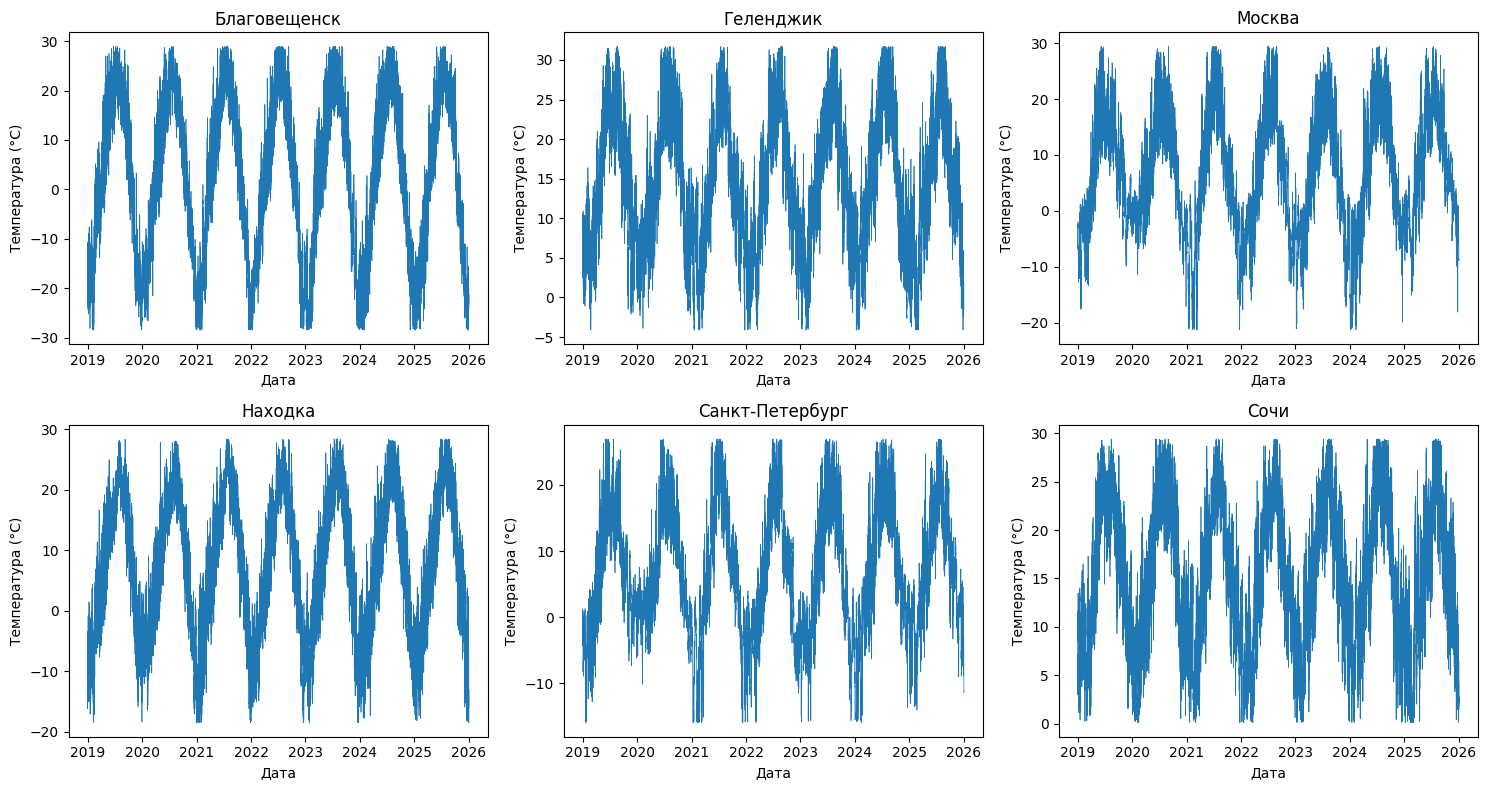

In [116]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, city in enumerate(data['city'].unique()):
    df_city = data[data['city'] == city].sort_values('ds')
    axes[i].plot(df_city['ds'], df_city['temperature_2m'], linewidth=0.5)
    axes[i].set_title(city)
    axes[i].set_xlabel('Дата')
    axes[i].set_ylabel('Температура (°C)')

plt.tight_layout()
plt.show()